In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os

In [ ]:
train_directory = r'Directory to training dataset'
test_directory = r'Directory to testing dataset'
validation_directory = r'directory to validation dataset'

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
#we need to convert jpeg to rgb pixels thats why we imported above function
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_gene = train_datagen.flow_from_directory(train_directory,
                                               target_size= (150,150),
                                               batch_size= 20,
                                               class_mode= 'binary')
test_gene = test_datagen.flow_from_directory(test_directory,
                                               target_size= (150,150),
                                               batch_size= 20,
                                               class_mode= 'binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [5]:
from keras import *

In [6]:
model = keras.models.Sequential()
model.add(layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, kernel_size=(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, kernel_size=(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, kernel_size=(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(512,activation='relu'))

model.add(layers.Dense(1,activation='sigmoid'))

c:\Users\ajink\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras import optimizers

In [9]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.Adam(learning_rate= 0.0001),
              metrics= ['acc'])

In [10]:
validation_gene = validation_datagen.flow_from_directory(validation_directory,
                                               target_size= (150,150),
                                               batch_size= 20,
                                               class_mode= 'binary')

Found 1000 images belonging to 2 classes.


steps per epochs = amount of train data/batch size = 2000/20 = 100 

In [11]:
model_history = model.fit(train_gene,
                        #   steps_per_epoch=100,
                          epochs=20,
                          batch_size=20,
                          validation_data=validation_gene,)
                          # validation_steps=50)

Epoch 1/20


c:\Users\ajink\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 364ms/step - acc: 0.5082 - loss: 0.6983 - val_acc: 0.5870 - val_loss: 0.6818
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 315ms/step - acc: 0.6009 - loss: 0.6678 - val_acc: 0.6320 - val_loss: 0.6650
Epoch 3/20
 80/100 ━━━━━━━━━━━━━━━━━━━━ 7s 352ms/step - acc: 0.6651 - loss: 0.6356

KeyboardInterrupt: 

In [54]:
for key, values in model_history.history.items():
    print(f"{key}: {len(values)}")

acc: 20
loss: 20
val_acc: 20
val_loss: 20


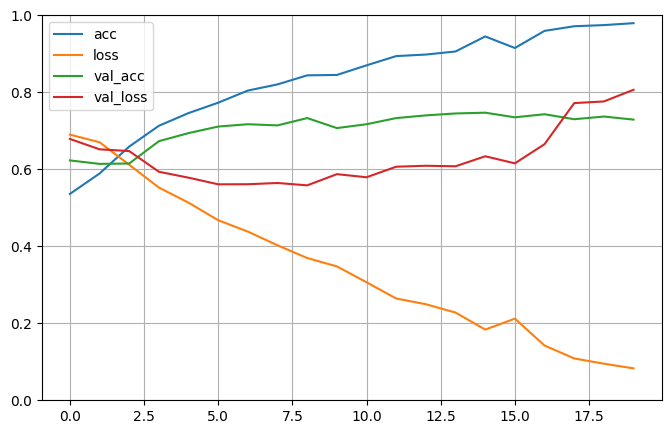

In [55]:
pd.DataFrame(model_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Data Augumentation

to change same images by rotating , shearing inc/dec height width

In [59]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,#it means -40 to 40 deg
                                   width_shift_range= 0.2,#20% of width can be +/-
                                   height_shift_range= 0.2,
                                   shear_range= 0.2,
                                   horizontal_flip=True )#Mirror image

test_datagen= ImageDataGenerator(rescale=1./255)

train_gene = train_datagen.flow_from_directory(train_directory,
                                                   target_size=(150,150),
                                                   class_mode= 'binary')
validation_gene = test_datagen.flow_from_directory(validation_directory,
                                                   target_size=(150,150),
                                                   class_mode= 'binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [63]:
model1 = keras.models.Sequential()
model1.add(layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(150,150,3)))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Conv2D(64, kernel_size=(3,3),activation='relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Conv2D(128, kernel_size=(3,3),activation='relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Conv2D(128, kernel_size=(3,3),activation='relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Flatten())
model1.add(layers.Dropout(0.5))   # To avoid overfitting it deactivates randomly 50% neurons
model1.add(layers.Dense(512,activation='relu'))

model1.add(layers.Dense(1,activation='sigmoid'))

model1.compile(loss='binary_crossentropy',
               optimizer= optimizers.Adam(learning_rate=0.0001),
               metrics= ['acc'])

c:\Users\ajink\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
history = model1.fit(train_gene,
                     batch_size=32,
                     validation_data = validation_gene,
                     epochs=20)

Epoch 1/20


c:\Users\ajink\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 562ms/step - acc: 0.4873 - loss: 0.6981 - val_acc: 0.5570 - val_loss: 0.6873
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 535ms/step - acc: 0.5300 - loss: 0.6886 - val_acc: 0.5880 - val_loss: 0.6679
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 523ms/step - acc: 0.5724 - loss: 0.6742 - val_acc: 0.5490 - val_loss: 0.6829
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 522ms/step - acc: 0.5561 - loss: 0.6803 - val_acc: 0.5980 - val_loss: 0.6598
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 508ms/step - acc: 0.6069 - loss: 0.6594 - val_acc: 0.6250 - val_loss: 0.6335
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 518ms/step - acc: 0.6114 - loss: 0.6500 - val_acc: 0.6530 - val_loss: 0.6116
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 500ms/step - acc: 0.6325 - loss: 0.6399 - val_acc: 0.6880 - val_loss: 0.6001
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 494ms/step - acc: 0.6672 - loss: 0.6142 - val_acc: 0.6090 - val_loss: 0.6497
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 525ms/step - acc:

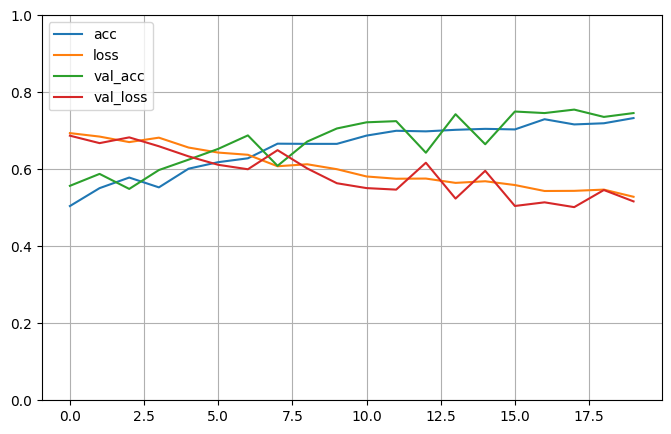

In [65]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()